## Random Forest model

In [198]:
# Cargar el archivo CSV
import pandas as pd
import numpy as np
import error_metrics
import pipeline

csv_path = "../DataFinal.csv"
df = pd.read_csv(csv_path)
print(df.shape)

(117, 45)


## Train/Test

In [199]:
from sklearn.model_selection import train_test_split
import LSTM
data = df.copy()
data.pop("Total Nacimientos")
X_all, y_all = LSTM.preparar_series_lstm(df, 10)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, 
    test_size=0.2, 
    shuffle=False, 
    random_state=61023521)
X_train = X_train.reshape(85,-1)
X_test = X_test.reshape(22,-1)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(85, 200) (85,)
(22, 200) (22,)


## Pipeline

In [200]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer


## Funciones

In [201]:
import matplotlib.pyplot as plt
seed = 641234

def plot_predictions(y_test, y_pred, title):
    plt.title(title)
    plt.plot(y_pred, '-o', label="Predicción")
    plt.plot(y_test,'-x', label="Original")
    plt.xlabel("Indice")
    plt.ylabel("Total de Nacimientos")
    plt.legend()
    plt.show()

## Params:


In [202]:
#  'randomforestregressor__max_depth': None,
#  'randomforestregressor__n_estimators': 100,
#  'randomforestregressor__min_samples_leaf': 1,
#  'randomforestregressor__min_samples_split': 2,
#  'randomforestregressor__max_features': 1.0,
#  'randomforestregressor__bootstrap': True,
#  'randomforestregressor__criterion': 'squared_error',

In [203]:
from sklearn.ensemble import RandomForestRegressor
from pipeline import crear_pipeline_random_forest
rf_1 = crear_pipeline_random_forest( RandomForestRegressor(random_state=seed))
print(rf_1.get_params())


{'memory': None, 'steps': [('imputer', SimpleImputer()), ('model', RandomForestRegressor(random_state=641234))], 'transform_input': None, 'verbose': False, 'imputer': SimpleImputer(), 'model': RandomForestRegressor(random_state=641234), 'imputer__add_indicator': False, 'imputer__copy': True, 'imputer__fill_value': None, 'imputer__keep_empty_features': False, 'imputer__missing_values': nan, 'imputer__strategy': 'mean', 'model__bootstrap': True, 'model__ccp_alpha': 0.0, 'model__criterion': 'squared_error', 'model__max_depth': None, 'model__max_features': 1.0, 'model__max_leaf_nodes': None, 'model__max_samples': None, 'model__min_impurity_decrease': 0.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__min_weight_fraction_leaf': 0.0, 'model__monotonic_cst': None, 'model__n_estimators': 100, 'model__n_jobs': None, 'model__oob_score': False, 'model__random_state': 641234, 'model__verbose': 0, 'model__warm_start': False}


## Model 1
Squared Error

In [204]:
from sklearn.model_selection import GridSearchCV
rf_1 = crear_pipeline_random_forest( RandomForestRegressor(random_state=seed, criterion='squared_error'))
param_grid = {
    'model__max_depth': [5,10,20,30],
    "model__bootstrap": [True, False],
    'model__n_estimators': [50,100,150,200],
    'model__max_features': ['sqrt', 'log2', 1.0]
}
gs1 = GridSearchCV(
    rf_1,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs1.fit(X_train, y_train)
best_model1= gs1.best_estimator_
print("Best Params: ",gs1.best_params_)
print("Best RMSE", np.sqrt(-gs1.best_score_))


Best Params:  {'model__bootstrap': False, 'model__max_depth': 20, 'model__max_features': 'log2', 'model__n_estimators': 200}
Best RMSE 2090.5488924648193


Random Forest #1:
MAE: 3650.939545454546
MSE: 21338176.386947736
RMSE: 4619.326399698092
R²: 0.9832541054751192


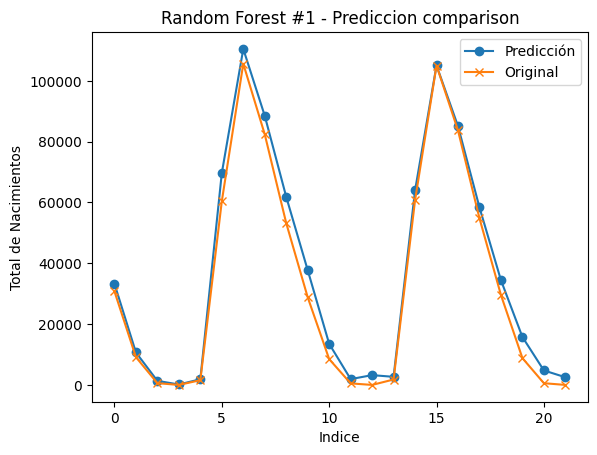

In [205]:
y_rf_1 = best_model1.predict(X_test)
error_metrics.calculate_errors(y_rf_1, y_test, "Random Forest #1")
plot_predictions(y_test, y_rf_1, "Random Forest #1 - Prediccion comparison")

### Overfitting

In [206]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
def ovefitting_test(model):
    y_pred = best_model1.predict(X_test)
    val_mse = np.sqrt(mean_squared_error(y_test, y_pred))
        
    cv_scores = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='neg_mean_squared_error',
    )
    train_rsme= np.sqrt(-cv_scores.mean())
    overfit_ratio = val_mse / train_rsme
    print(f"Train RMSE: {train_rsme:.4f}")
    print(f"Validation RMSE: {val_mse:.4f}")
    print(f"Overfit Ratio (val/train): {overfit_ratio:.2f}")

ovefitting_test(best_model1)

Train RMSE: 2090.5489
Validation RMSE: 4619.3264
Overfit Ratio (val/train): 2.21


## Modelo 2

In [207]:
rf_2 = crear_pipeline_random_forest( RandomForestRegressor(random_state=seed, criterion='poisson'))
param_grid = {
    'model__max_depth': [5,10,20,30],
    "model__bootstrap": [True, False],
    'model__n_estimators': [50,100,150,200],
    'model__max_features': ['sqrt', 'log2', 1.0],
}
gs2 = GridSearchCV(
    rf_2,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs2.fit(X_train, y_train)
best_model2= gs2.best_estimator_
print("Best Params: ",gs2.best_params_)
print("Best RMSE", np.sqrt(-gs2.best_score_))

Best Params:  {'model__bootstrap': False, 'model__max_depth': 10, 'model__max_features': 'log2', 'model__n_estimators': 150}
Best RMSE 2205.9492299453177


Random Forest #2:
MAE: 3906.6306565656564
MSE: 20998170.88372194
RMSE: 4582.376117662314
R²: 0.9835209369133662


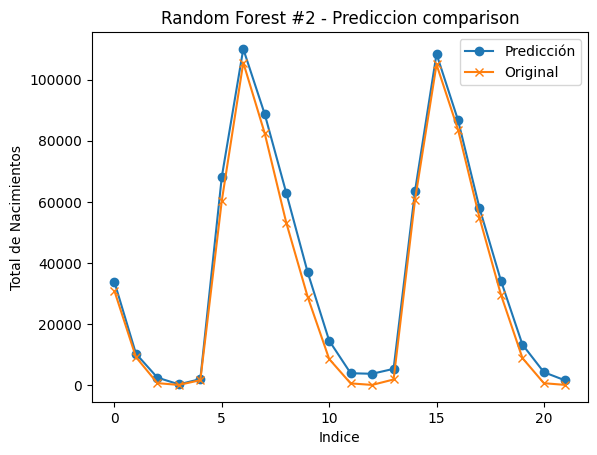

In [208]:
y_rf_2 = best_model2.predict(X_test)
error_metrics.calculate_errors(y_rf_2, y_test, "Random Forest #2")
plot_predictions(y_test, y_rf_2, "Random Forest #2 - Prediccion comparison")

In [209]:
ovefitting_test(best_model2)

Train RMSE: 2205.9492
Validation RMSE: 4619.3264
Overfit Ratio (val/train): 2.09


## Modelo 3

In [210]:
rf_3 = crear_pipeline_random_forest( RandomForestRegressor(random_state=seed, criterion='friedman_mse'))
param_grid = {
    'model__max_depth': [5,10,20,30],
    "model__bootstrap": [True, False],
    'model__n_estimators': [50,100,150,200],
    'model__max_features': ['sqrt', 'log2', 1.0],
}
gs3 = GridSearchCV(
    rf_3,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs3.fit(X_train, y_train)
best_model3= gs3.best_estimator_
print("Best Params: ",gs3.best_params_)
print("Best RMSE", np.sqrt(-gs3.best_score_))

Best Params:  {'model__bootstrap': False, 'model__max_depth': 20, 'model__max_features': 'log2', 'model__n_estimators': 200}
Best RMSE 2090.5488924648193


Random Forest #3:
MAE: 3650.939545454546
MSE: 21338176.386947736
RMSE: 4619.326399698092
R²: 0.9832541054751192


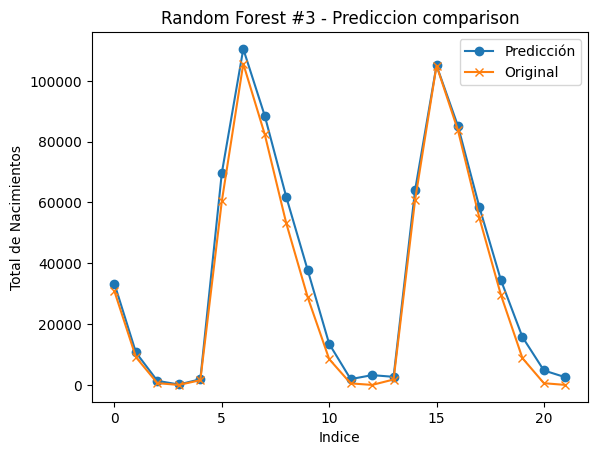

In [213]:
y_rf_3 = best_model3.predict(X_test)
error_metrics.calculate_errors(y_rf_3, y_test, "Random Forest #3")
plot_predictions(y_test, y_rf_3,"Random Forest #3 - Prediccion comparison")

In [215]:
ovefitting_test(best_model3)

Train RMSE: 2090.5489
Validation RMSE: 4619.3264
Overfit Ratio (val/train): 2.21
